# Thesis — Part 1: Machine Learning Predictive Analytics
---

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Traditional ML Models (matching SmartScanPCOS)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier,
                               HistGradientBoostingClassifier, StackingClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, matthews_corrcoef, make_scorer)

# Feature Selection
from sklearn.feature_selection import mutual_info_classif

# Class Imbalance
from imblearn.over_sampling import SMOTE, BorderlineSMOTE

# XAI Libraries
import shap
# from pdpbox import pdp  # For PDP plots
# from lime import lime_tabular  # For LIME
# from shapash import SmartExplainer  # For Smart Predictor

import pickle

# Set seeds
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [ ]:
df_train_raw  = pd.read_csv('Training Dataset(Pcos).csv')
df_test_raw = pd.read_excel('TestingData(1331).xlsx')


In [ ]:
print(f"Training data shape: {df_train_raw.shape}")
print(f"Test data shape: {df_test_raw.shape}")

Training data shape: (2000, 44)
Test data shape: (1331, 45)


In [ ]:
print("="*80)
print("TRAINING DATA OVERVIEW")
print("="*80)
print(df_train_raw.head())


TRAINING DATA OVERVIEW
   Sl. No  Patient File No.  PCOS (Y/N)   Age (yrs)  Weight (Kg)  Height(Cm)   \
0     193               193           0          30    69.979147   167.708055   
1     360               360           0          36    63.711688   154.055877   
2      10                10           0          36    51.848631   149.059804   
3     278               278           1          29    66.893988   148.628036   
4      71                71           0          33    52.536198   150.767409   

         BMI  Blood Group  Pulse rate(bpm)   RR (breaths/min)  ...  \
0  24.880597           12                72                22  ...   
1  26.844949           13                70                18  ...   
2  23.335451           15                80                20  ...   
3  30.282074           15                72                18  ...   
4  23.112328           13                72                18  ...   

   Pimples(Y/N)  Fast food (Y/N)  Reg.Exercise(Y/N)  BP _Systolic (mm

In [ ]:
print("\nData Types:")
print(df_train_raw.dtypes)



Data Types:
Sl. No                      int64
Patient File No.            int64
PCOS (Y/N)                  int64
 Age (yrs)                  int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of abortions            int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)     object
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                 object
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                float64
R

In [ ]:
print("\nMissing Values:")
print(df_train_raw.isnull().sum())


Missing Values:
Sl. No                    0
Patient File No.          0
PCOS (Y/N)                0
 Age (yrs)                0
Weight (Kg)               0
Height(Cm)                0
BMI                       0
Blood Group               0
Pulse rate(bpm)           0
RR (breaths/min)          0
Hb(g/dl)                  0
Cycle(R/I)                0
Cycle length(days)        0
Marraige Status (Yrs)     3
Pregnant(Y/N)             0
No. of abortions          0
  I   beta-HCG(mIU/mL)    0
II    beta-HCG(mIU/mL)    0
FSH(mIU/mL)               0
LH(mIU/mL)                0
FSH/LH                    0
Hip(inch)                 0
Waist(inch)               0
Waist:Hip Ratio           0
TSH (mIU/L)               0
AMH(ng/mL)                0
PRL(ng/mL)                0
Vit D3 (ng/mL)            0
PRG(ng/mL)                0
RBS(mg/dl)                0
Weight gain(Y/N)          0
hair growth(Y/N)          0
Skin darkening (Y/N)      0
Hair loss(Y/N)            0
Pimples(Y/N)              0
Fas

In [ ]:
print("\nBasic Statistics:")
print(df_train_raw.describe())


Basic Statistics:
            Sl. No  Patient File No.   PCOS (Y/N)   Age (yrs)  Weight (Kg)  \
count  2000.000000       2000.000000  2000.000000  2000.00000  2000.000000   
mean    266.633000        266.633000     0.304000    31.35400    59.527068   
std     154.058467        154.058467     0.460098     5.44982    11.445212   
min       1.000000          1.000000     0.000000    20.00000    30.739215   
25%     132.000000        132.000000     0.000000    28.00000    52.248684   
50%     267.000000        267.000000     0.000000    31.00000    58.538632   
75%     395.000000        395.000000     1.000000    35.00000    65.519518   
max     541.000000        541.000000     1.000000    48.00000   113.379053   

       Height(Cm)           BMI  Blood Group  Pulse rate(bpm)   \
count  2000.000000  2000.000000  2000.000000       2000.000000   
mean    156.416496    24.285762    13.788000         73.241000   
std       6.044243     4.160666     1.832958          4.098941   
min     136.53

In [ ]:
if 'PCOS (Y/N)' in df_train_raw.columns:
    print("\nTarget Variable Distribution:")
    print(df_train_raw['PCOS (Y/N)'].value_counts())
    print("\nPercentage:")
    print(df_train_raw['PCOS (Y/N)'].value_counts(normalize=True) * 100)


Target Variable Distribution:
PCOS (Y/N)
0    1392
1     608
Name: count, dtype: int64

Percentage:
PCOS (Y/N)
0    69.6
1    30.4
Name: proportion, dtype: float64


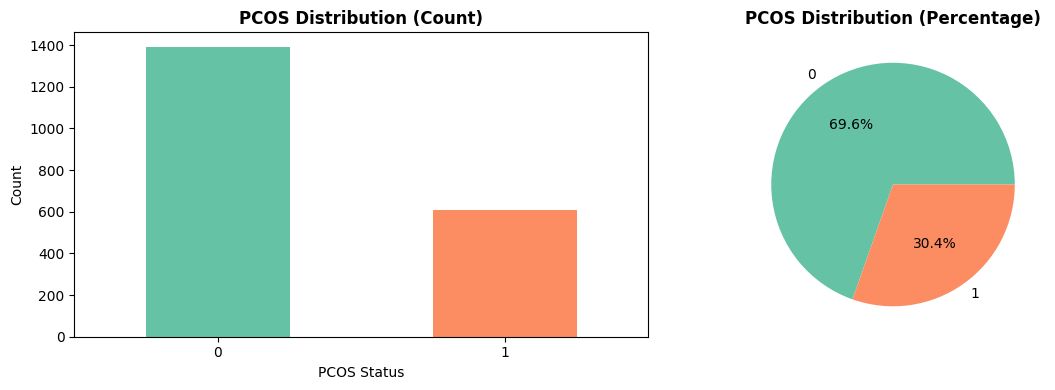

In [ ]:

# Visualize target distribution (Train)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

df_train_raw['PCOS (Y/N)'].value_counts().plot(kind='bar', ax=ax[0], color=['#66c2a5', '#fc8d62'])
ax[0].set_title('PCOS Distribution (Count)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('PCOS Status')
ax[0].set_ylabel('Count')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

df_train_raw['PCOS (Y/N)'].value_counts(normalize=True).plot(
  kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62']
    )
ax[1].set_title('PCOS Distribution (Percentage)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()



In [ ]:
def basic_clean(df):
    df = df.copy()
    df.columns = df.columns.str.strip()
    df.replace(['?', ' ', '', 'None', 'nan','NaN'], np.nan, inplace=True)
    return df

In [ ]:
df_train_clean = basic_clean(df_train_raw)
df_test_clean = basic_clean(df_test_raw)

print("\n✓ Basic cleaning completed")
print(f"Training data shape: {df_train_clean.shape}")
print(f"Test data shape: {df_test_clean.shape}")


✓ Basic cleaning completed
Training data shape: (2000, 44)
Test data shape: (1331, 45)


In [ ]:
id_cols = ['Sl. No', 'Patient File No.']
cols_to_drop = [col for col in id_cols if col in df_train_clean.columns]

if cols_to_drop:
    df_train_clean.drop(columns=cols_to_drop, inplace=True)
    df_test_clean.drop(columns=[c for c in cols_to_drop if c in df_test_clean.columns], inplace=True)
    print(f"✓ Removed identifier columns: {cols_to_drop}")

✓ Removed identifier columns: ['Sl. No', 'Patient File No.']


In [ ]:
# Remove unnamed columns
unnamed_cols = [col for col in df_train_clean.columns if 'Unnamed' in col]
if unnamed_cols:
    df_train_clean.drop(columns=unnamed_cols, inplace=True)
    df_test_clean.drop(columns=[c for c in unnamed_cols if c in df_test_clean.columns], inplace=True)
    print(f"✓ Removed unnamed columns: {len(unnamed_cols)}")

print(f"\nFeatures after cleaning: {df_train_clean.shape[1]}")



Features after cleaning: 42


In [ ]:
# Analyze missing values BEFORE any removal
print("\n" + "="*80)
print("MISSING VALUES ANALYSIS (BEFORE HANDLING)")
print("="*80)

print("\nTraining data missing values:")
missing_train = df_train_clean.isnull().sum()
missing_train_pct = (missing_train / len(df_train_clean)) * 100
missing_train_df = pd.DataFrame({
    'Missing Count': missing_train,
    'Percentage': missing_train_pct
})
missing_summary_train = missing_train_df[missing_train_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_summary_train) > 0:
    print(missing_summary_train)
else:
    print("No missing values found!")

print("\nTest data missing values:")
missing_test = df_test_clean.isnull().sum()
missing_test_pct = (missing_test / len(df_test_clean)) * 100
missing_test_df = pd.DataFrame({
    'Missing Count': missing_test,
    'Percentage': missing_test_pct
})
missing_summary_test = missing_test_df[missing_test_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_summary_test) > 0:
    print(missing_summary_test)
else:
    print("No missing values found!")


MISSING VALUES ANALYSIS (BEFORE HANDLING)

Training data missing values:
                       Missing Count  Percentage
Marraige Status (Yrs)              3        0.15

Test data missing values:
             Missing Count  Percentage
Unnamed: 44           1331       100.0


In [ ]:
# Encode features (SmartScanPCOS encoding scheme)
def encode_features(df_train, df_test, target_col='PCOS (Y/N)'):
    """
    Encoding as per SmartScanPCOS paper:
    - Binary Y/N → 1/0
    - Blood Group → Keep numeric (11-18 as per your dataset)
    - Target → 1/0
    """
    df_train = df_train.copy()
    df_test = df_test.copy()

    # Binary Y/N columns
    binary_cols = ['Pregnant(Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
                   'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
                   'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

    for col in binary_cols:
        if col in df_train.columns:
            df_train[col] = df_train[col].map({'Y': 1, 'N': 0, 1: 1, 0: 0})
        if col in df_test.columns:
            df_test[col] = df_test[col].map({'Y': 1, 'N': 0, 1: 1, 0: 0})

    # Cycle regularity
    if 'Cycle(R/I)' in df_train.columns:
        df_train['Cycle(R/I)'] = df_train['Cycle(R/I)'].map({'R': 0, 'I': 1, 0: 0, 1: 1})
    if 'Cycle(R/I)' in df_test.columns:
        df_test['Cycle(R/I)'] = df_test['Cycle(R/I)'].map({'R': 0, 'I': 1, 0: 0, 1: 1})

    # Target variable
    if target_col in df_train.columns:
        df_train[target_col] = df_train[target_col].map({'Y': 1, 'N': 0, 1: 1, 0: 0})

    # Blood Group - already numeric 11-18, just ensure type
    if 'Blood Group' in df_train.columns:
        df_train['Blood Group'] = pd.to_numeric(df_train['Blood Group'], errors='coerce')
    if 'Blood Group' in df_test.columns:
        df_test['Blood Group'] = pd.to_numeric(df_test['Blood Group'], errors='coerce')

    return df_train, df_test

df_train_clean, df_test_clean = encode_features(df_train_clean, df_test_clean)
print(f"\n✓ Features encoded (Y/N → 1/0)")



✓ Features encoded (Y/N → 1/0)


In [ ]:
# Remove all-NaN columns
all_nan_train = df_train_clean.columns[df_train_clean.isna().all()].tolist()
if all_nan_train:
    df_train_clean.drop(columns=all_nan_train, inplace=True)
    df_test_clean.drop(columns=[c for c in all_nan_train if c in df_test_clean.columns], inplace=True)
    print(f"✓ Removed {len(all_nan_train)} all-NaN columns")

print(f"\n✓ Data preprocessing complete")
print(f"  Final training shape: {df_train_clean.shape}")
print(f"  Final test shape: {df_test_clean.shape}")
print(f"  Features: {df_train_clean.shape[1] - 1}")  # -1 for target


✓ Removed 1 all-NaN columns

✓ Data preprocessing complete
  Final training shape: (2000, 41)
  Final test shape: (1331, 42)
  Features: 40


In [ ]:
# Apply feature encoding
df_train_clean, df_test_clean = encode_features(df_train_clean, df_test_clean)

print("\n" + "="*80)
print("DATA PREPROCESSING SUMMARY")
print("="*80)
print(f"Final training data shape: {df_train_clean.shape}")
print(f"Final test data shape: {df_test_clean.shape}")
print(f"Number of features (including target): {df_train_clean.shape[1]}")
print(f"Number of predictive features: {df_train_clean.shape[1] - 1}")


DATA PREPROCESSING SUMMARY
Final training data shape: (2000, 41)
Final test data shape: (1331, 42)
Number of features (including target): 41
Number of predictive features: 40


In [ ]:
# Verify Target Variable Encoding
target_col = 'PCOS (Y/N)'

if target_col in df_train_clean.columns:
    if df_train_clean[target_col].dtype == 'object':
        print(f"Target variable '{target_col}' is currently of type 'object'. Expected 'int64' or 'float64'.")
        print("Consider encoding 'Y'/'N' to 1/0 if this is intended.")
    else:
        print(f"✓ Target variable '{target_col}' is already numeric (type: {df_train_clean[target_col].dtype}).")
        print(f"  Unique values: {df_train_clean[target_col].unique()}")
        print("  No further encoding for 'Y'/'N' to 1/0 is needed.")
else:
    print(f"Target variable '{target_col}' not found in df_train_clean.")

✓ Target variable 'PCOS (Y/N)' is already numeric (type: int64).
  Unique values: [0 1]
  No further encoding for 'Y'/'N' to 1/0 is needed.


In [ ]:
# 3. TRAIN/VALIDATION/TEST SPLIT (70/15/15 as per SmartScanPCOS)
# ============================================================================

print("\n" + "="*80)
print("3. DATA SPLITTING (70% Train / 15% Val / 15% Test)")
print("="*80)

X = df_train_clean.drop(columns=['PCOS (Y/N)'])
y = df_train_clean['PCOS (Y/N)']

print(f"\nOriginal class distribution:")
print(f"  No PCOS (0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"  PCOS (1):    {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")



3. DATA SPLITTING (70% Train / 15% Val / 15% Test)

Original class distribution:
  No PCOS (0): 1392 (69.6%)
  PCOS (1):    608 (30.4%)


In [ ]:
# Split: 85% train+val, 15% test
X_trainval, X_test_p1, y_trainval, y_test_p1 = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

In [ ]:
# Split train+val: 70% train, 15% val
X_train_p1, X_val_p1, y_train_p1, y_val_p1 = train_test_split(
    X_trainval, y_trainval, test_size=0.176, random_state=RANDOM_STATE, stratify=y_trainval
)

In [ ]:
print(f"\nHold-out Split Summary:")
print(f"  Train : {len(X_train_p1)} samples ({len(X_train_p1)/len(X)*100:.1f}%)")
print(f"  Val   : {len(X_val_p1)} samples ({len(X_val_p1)/len(X)*100:.1f}%)")
print(f"  Test  : {len(X_test_p1)} samples ({len(X_test_p1)/len(X)*100:.1f}%)")


Hold-out Split Summary:
  Train : 1400 samples (70.0%)
  Val   : 300 samples (15.0%)
  Test  : 300 samples (15.0%)


In [ ]:
# ============================================================================
# STRATIFIED 10-FOLD CROSS VALIDATION (ON 70% TRAINING SET ONLY)
# ============================================================================

from sklearn.model_selection import StratifiedKFold
import pandas as pd

print("\n" + "="*80)
print("10-FOLD STRATIFIED K-FOLD (ON 70% TRAINING SET)")
print("="*80)

skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_results = []
fold_number = 1

for train_idx, val_idx in skf.split(X_train_p1, y_train_p1):

    X_fold_train = X_train_p1.iloc[train_idx]
    y_fold_train = y_train_p1.iloc[train_idx]

    X_fold_val = X_train_p1.iloc[val_idx]
    y_fold_val = y_train_p1.iloc[val_idx]

    fold_results.append({
        "Fold": fold_number,
        "Fold Train Size": len(X_fold_train),
        "Fold Validation Size": len(X_fold_val),
        "Fold Train PCOS %": y_fold_train.mean() * 100,
        "Fold Validation PCOS %": y_fold_val.mean() * 100
    })

    fold_number += 1

fold_df = pd.DataFrame(fold_results)

print("\nFold Distribution Summary:")
print(fold_df.round(2))


10-FOLD STRATIFIED K-FOLD (ON 70% TRAINING SET)

Fold Distribution Summary:
   Fold  Fold Train Size  Fold Validation Size  Fold Train PCOS %  \
0     1             1260                   140              30.40   
1     2             1260                   140              30.40   
2     3             1260                   140              30.40   
3     4             1260                   140              30.40   
4     5             1260                   140              30.40   
5     6             1260                   140              30.40   
6     7             1260                   140              30.48   
7     8             1260                   140              30.48   
8     9             1260                   140              30.48   
9    10             1260                   140              30.48   

   Fold Validation PCOS %  
0                   30.71  
1                   30.71  
2                   30.71  
3                   30.71  
4                   30.

In [ ]:
# Check class distribution
print("\nClass Distribution:")
print(f"Training   - Positive: {y_train_p1.sum()} ({y_train_p1.sum()/len(y_train_p1)*100:.1f}%), Negative: {len(y_train_p1) - y_train_p1.sum()} ({(len(y_train_p1) - y_train_p1.sum())/len(y_train_p1)*100:.1f}%)")
print(f"Validation - Positive: {y_val_p1.sum()} ({y_val_p1.sum()/len(y_val_p1)*100:.1f}%), Negative: {len(y_val_p1) - y_val_p1.sum()} ({(len(y_val_p1) - y_val_p1.sum())/len(y_val_p1)*100:.1f}%)")
print(f"Test       - Positive: {y_test_p1.sum()} ({y_test_p1.sum()/len(y_test_p1)*100:.1f}%), Negative: {len(y_test_p1) - y_test_p1.sum()} ({(len(y_test_p1) - y_test_p1.sum())/len(y_test_p1)*100:.1f}%)")


Class Distribution:
Training   - Positive: 426 (30.4%), Negative: 974 (69.6%)
Validation - Positive: 91 (30.3%), Negative: 209 (69.7%)
Test       - Positive: 91 (30.3%), Negative: 209 (69.7%)


In [ ]:
# 4. IMPUTATION & SCALING
# ============================================================================

print("\n" + "="*80)
print("4. MISSING VALUE IMPUTATION & FEATURE SCALING")
print("="*80)

# Convert all to numeric
print("\nConverting all features to numeric...")
for col in X_train_p1.columns:
    X_train_p1[col] = pd.to_numeric(X_train_p1[col], errors='coerce')
    X_val_p1[col] = pd.to_numeric(X_val_p1[col], errors='coerce')
    X_test_p1[col] = pd.to_numeric(X_test_p1[col], errors='coerce')

# Remove columns that became all-NaN
all_nan_cols = X_train_p1.columns[X_train_p1.isna().all()].tolist()
if all_nan_cols:
    print(f"Removing {len(all_nan_cols)} all-NaN columns: {all_nan_cols}")
    X_train_p1 = X_train_p1.drop(columns=all_nan_cols)
    X_val_p1 = X_val_p1.drop(columns=all_nan_cols)
    X_test_p1 = X_test_p1.drop(columns=all_nan_cols)

feature_names_p1 = X_train_p1.columns.tolist()
print(f"\nFinal feature count: {len(feature_names_p1)}")


4. MISSING VALUE IMPUTATION & FEATURE SCALING

Converting all features to numeric...

Final feature count: 40


In [ ]:
# Imputation with median (SmartScanPCOS approach)
imputer_p1 = SimpleImputer(strategy='median')

X_train_imputed_p1 = pd.DataFrame(
    imputer_p1.fit_transform(X_train_p1),
    columns=feature_names_p1,
    index=X_train_p1.index
)
X_val_imputed_p1 = pd.DataFrame(
    imputer_p1.transform(X_val_p1),
    columns=feature_names_p1,
    index=X_val_p1.index
)
X_test_imputed_p1 = pd.DataFrame(
    imputer_p1.transform(X_test_p1),
    columns=feature_names_p1,
    index=X_test_p1.index
)

print(f"✓ Missing values imputed (median strategy)")


✓ Missing values imputed (median strategy)


In [ ]:
# Standardization (Zero mean, unit variance)
scaler_p1 = StandardScaler()
X_train_scaled_p1 = scaler_p1.fit_transform(X_train_imputed_p1)
X_val_scaled_p1 = scaler_p1.transform(X_val_imputed_p1)
X_test_scaled_p1 = scaler_p1.transform(X_test_imputed_p1)

print(f"✓ Features standardized (StandardScaler)")


✓ Features standardized (StandardScaler)


In [ ]:
# 5. CLASS BALANCING - BORDERLINE SMOTE (SmartScanPCOS Eq. 1)
# ============================================================================

print("\n" + "="*80)
print("5. CLASS BALANCING (Borderline-SMOTE)")
print("="*80)

print(f"\nBefore SMOTE:")
print(f"  Total: {len(y_train_p1)}")
print(f"  Class 0: {(y_train_p1==0).sum()}")
print(f"  Class 1: {(y_train_p1==1).sum()}")



5. CLASS BALANCING (Borderline-SMOTE)

Before SMOTE:
  Total: 1400
  Class 0: 974
  Class 1: 426


In [ ]:
# Apply Borderline-SMOTE (as per SmartScanPCOS Section 3.2)
smote = BorderlineSMOTE(random_state=RANDOM_STATE)
X_train_balanced_p1, y_train_balanced = smote.fit_resample(X_train_scaled_p1, y_train_p1)

print(f"\nAfter Borderline-SMOTE:")
print(f"  Total: {len(y_train_balanced)}")
print(f"  Class 0: {(y_train_balanced==0).sum()}")
print(f"  Class 1: {(y_train_balanced==1).sum()}")
print(f"✓ Perfect balance achieved (1:1 ratio)")


After Borderline-SMOTE:
  Total: 1948
  Class 0: 974
  Class 1: 974
✓ Perfect balance achieved (1:1 ratio)


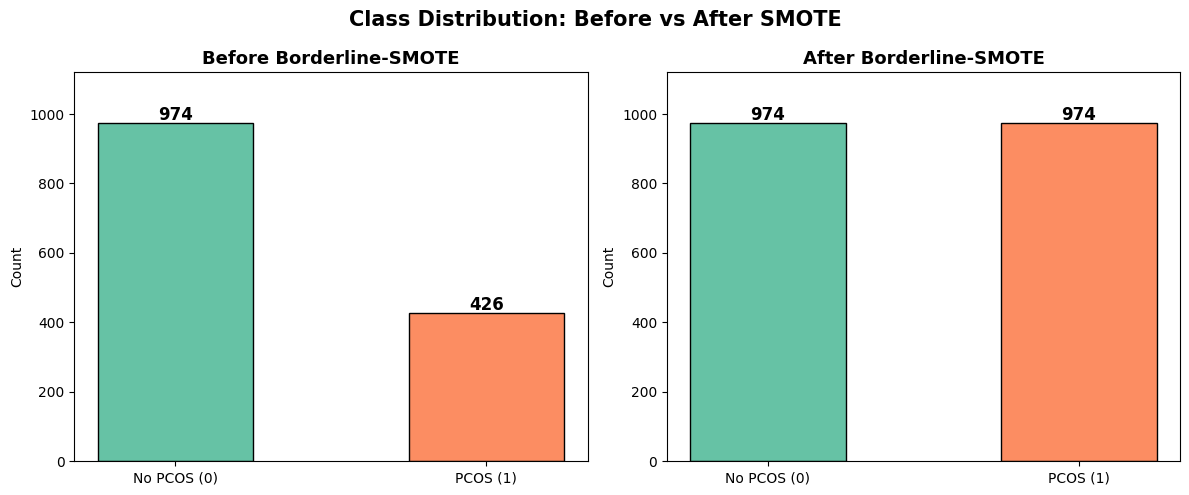

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
before_counts = pd.Series(y_train_p1).value_counts()
axes[0].bar(['No PCOS (0)', 'PCOS (1)'], before_counts.values,
            color=['#66c2a5', '#fc8d62'], edgecolor='black', width=0.5)
for i, v in enumerate(before_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Before Borderline-SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(before_counts.values) * 1.15)

# After SMOTE
after_counts = pd.Series(y_train_balanced).value_counts()
axes[1].bar(['No PCOS (0)', 'PCOS (1)'], after_counts.values,
            color=['#66c2a5', '#fc8d62'], edgecolor='black', width=0.5)
for i, v in enumerate(after_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('After Borderline-SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, max(after_counts.values) * 1.15)

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

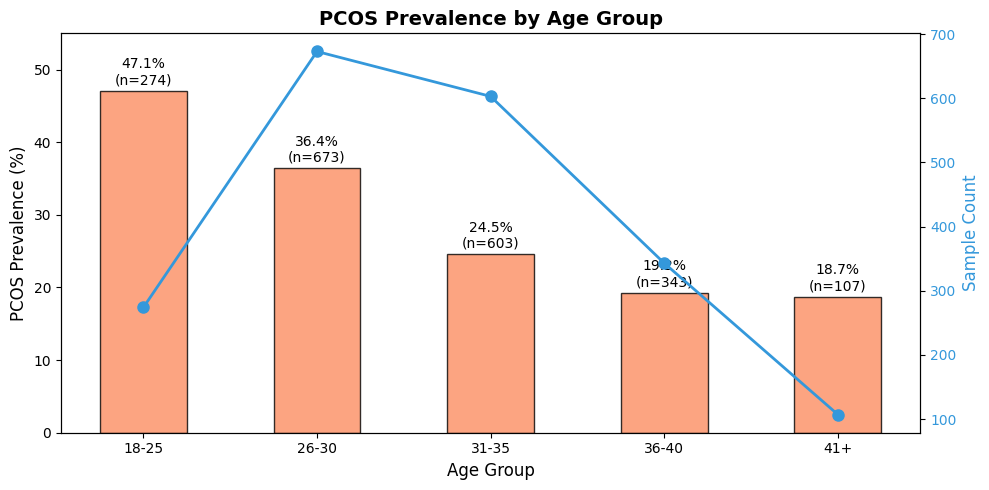

In [ ]:
df_age = df_train_clean.copy()
df_age['Age Group'] = pd.cut(df_age['Age (yrs)'],
                              bins=[18, 25, 30, 35, 40, 50],
                              labels=['18-25', '26-30', '31-35', '36-40', '41+'])

age_pcos = df_age.groupby('Age Group', observed=True)['PCOS (Y/N)'].agg(['mean', 'count']).reset_index()
age_pcos.columns = ['Age Group', 'PCOS Rate', 'Count']
age_pcos['PCOS Rate'] = age_pcos['PCOS Rate'] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
bars = ax1.bar(age_pcos['Age Group'], age_pcos['PCOS Rate'],
               color='#fc8d62', alpha=0.8, edgecolor='black', width=0.5)
ax1.set_ylabel('PCOS Prevalence (%)', fontsize=12)
ax1.set_xlabel('Age Group', fontsize=12)
ax1.set_ylim(0, 55)

for bar, rate, count in zip(bars, age_pcos['PCOS Rate'], age_pcos['Count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%\n(n={count})', ha='center', va='bottom', fontsize=10)

ax2 = ax1.twinx()
ax2.plot(age_pcos['Age Group'], age_pcos['Count'],
         color='#3498db', marker='o', linewidth=2, markersize=8, label='Sample Count')
ax2.set_ylabel('Sample Count', fontsize=12, color='#3498db')
ax2.tick_params(axis='y', labelcolor='#3498db')

plt.title('PCOS Prevalence by Age Group', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# 6. FEATURE SELECTION - TOMIM (SmartScanPCOS Section 3.3.3)
# ============================================================================

print("\n" + "="*80)
print("6. FEATURE SELECTION - TOMIM (Best from SmartScanPCOS)")
print("="*80)

# Calculate Mutual Information scores
mi_scores = mutual_info_classif(X_train_balanced_p1, y_train_balanced, random_state=RANDOM_STATE)

# Threshold = mean of MI scores (SmartScanPCOS Equation 4)
threshold = mi_scores.mean()
print(f"\nMutual Information threshold (mean): {threshold:.4f}")

# Select features above threshold
selected_indices_p1 = [i for i, score in enumerate(mi_scores) if score > threshold]
selected_features_p1 = [feature_names_p1[i] for i in selected_indices_p1]

print(f"\n✓ TOMIM selected {len(selected_features_p1)} features:")
for i, feat in enumerate(selected_features_p1, 1):
    print(f"  {i:2d}. {feat:30s} (MI: {mi_scores[feature_names_p1.index(feat)]:.4f})")



6. FEATURE SELECTION - TOMIM (Best from SmartScanPCOS)

Mutual Information threshold (mean): 0.1380

✓ TOMIM selected 16 features:
   1. Hb(g/dl)                       (MI: 0.1604)
   2. I   beta-HCG(mIU/mL)           (MI: 0.2346)
   3. II    beta-HCG(mIU/mL)         (MI: 0.1398)
   4. FSH(mIU/mL)                    (MI: 0.3275)
   5. LH(mIU/mL)                     (MI: 0.2984)
   6. FSH/LH                         (MI: 0.3387)
   7. Waist(inch)                    (MI: 0.1423)
   8. TSH (mIU/L)                    (MI: 0.2857)
   9. AMH(ng/mL)                     (MI: 0.3350)
  10. PRL(ng/mL)                     (MI: 0.3966)
  11. Vit D3 (ng/mL)                 (MI: 0.2994)
  12. PRG(ng/mL)                     (MI: 0.1477)
  13. RBS(mg/dl)                     (MI: 0.1462)
  14. Follicle No. (L)               (MI: 0.2657)
  15. Follicle No. (R)               (MI: 0.2736)
  16. Avg. F size (L) (mm)           (MI: 0.1399)


In [ ]:
# Apply feature selection
X_train_selected_p1 = X_train_balanced_p1[:, selected_indices_p1]
X_val_selected_p1 = X_val_scaled_p1[:, selected_indices_p1]
X_test_selected_p1 = X_test_scaled_p1[:, selected_indices_p1]


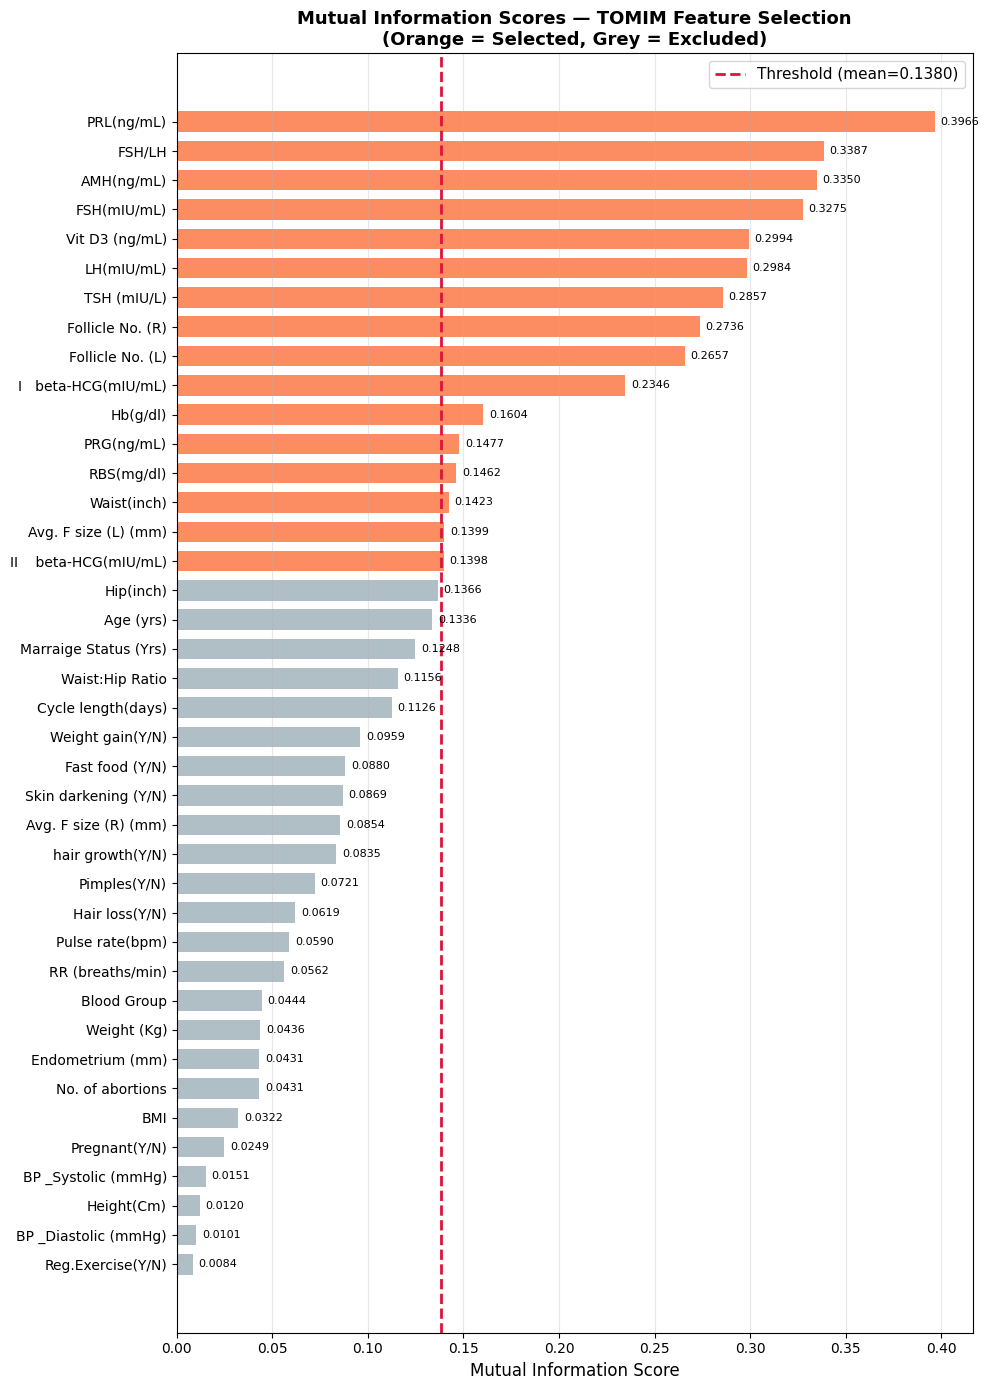

In [ ]:
mi_df = pd.DataFrame({
    'Feature': feature_names_p1,
    'MI Score': mi_scores
}).sort_values('MI Score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 14))
colors = ['#fc8d62' if s > threshold else '#b0bec5' for s in mi_df['MI Score']]
bars = ax.barh(mi_df['Feature'], mi_df['MI Score'], color=colors, edgecolor='none', height=0.7)

ax.axvline(x=threshold, color='crimson', linewidth=2, linestyle='--',
           label=f'Threshold (mean={threshold:.4f})')

for bar, val in zip(bars, mi_df['MI Score']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Mutual Information Scores — TOMIM Feature Selection\n(Orange = Selected, Grey = Excluded)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [ ]:

# ============================================================================
# 7. TRADITIONAL ML WITH HYPERPARAMETER TUNING
# ============================================================================

print("\n" + "="*80)
print("7. TRADITIONAL ML WITH HYPERPARAMETER TUNING")
print("="*80)

# Define parameter grids for each model
param_grids = {
    "Logistic Regression": {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga'],
        'max_iter': [1000]
    },
    "SVM": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    },
    "Decision Tree": {
        'max_depth': [5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    "K-Nearest Neighbors": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "AdaBoost": {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 1.0]
    },
    "XGBoost": {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.8, 1.0]
    },
    "Extra Trees": {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 15, 20],
        'min_samples_split': [2, 5]
    }
}

# Models without tuning (Naive Bayes has no critical hyperparameters)
simple_models = {
    "Naive Bayes": GaussianNB()
}

# Models requiring tuning
tunable_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE)
}

ml_results_p1 = {}
trained_models_p1 = {}
best_params_dict = {}

# F1 scorer for optimization
f1_scorer = make_scorer(f1_score)

print("\nPerforming GridSearchCV for each model...")
print("="*80)

for name, model in tunable_models.items():
    print(f"\nTuning {name}...")

    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring=f1_scorer,
        cv=8,  # 8-fold CV for speed
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_selected_p1, y_train_balanced)

    best_model = grid_search.best_estimator_
    best_params_dict[name] = grid_search.best_params_
    trained_models_p1[name] = best_model

    y_val_pred = best_model.predict(X_val_selected_p1)
    y_val_prob = best_model.predict_proba(X_val_selected_p1)[:, 1] if hasattr(best_model, 'predict_proba') else None

    ml_results_p1[name] = {
        'Accuracy': accuracy_score(y_val_p1, y_val_pred),
        'Precision': precision_score(y_val_p1, y_val_pred),
        'Recall': recall_score(y_val_p1, y_val_pred),
        'F1-Score': f1_score(y_val_p1, y_val_pred),
        'ROC-AUC': roc_auc_score(y_val_p1, y_val_prob) if y_val_prob is not None else None,
        'Best_Params': str(grid_search.best_params_)
    }

    print(f"  ✓ Best F1: {ml_results_p1[name]['F1-Score']:.4f}")
    print(f"  ✓ Best Params: {grid_search.best_params_}")

# Train simple models
for name, model in simple_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_selected_p1, y_train_balanced)
    trained_models_p1[name] = model

    y_val_pred = model.predict(X_val_selected_p1)
    y_val_prob = model.predict_proba(X_val_selected_p1)[:, 1] if hasattr(model, 'predict_proba') else None

    ml_results_p1[name] = {
        'Accuracy': accuracy_score(y_val_p1, y_val_pred),
        'Precision': precision_score(y_val_p1, y_val_pred),
        'Recall': recall_score(y_val_p1, y_val_pred),
        'F1-Score': f1_score(y_val_p1, y_val_pred),
        'ROC-AUC': roc_auc_score(y_val_p1, y_val_prob) if y_val_prob is not None else None,
        'Best_Params': 'N/A'
    }

ml_results_df = pd.DataFrame(ml_results_p1).T.sort_values('F1-Score', ascending=False)

print("\n" + "="*80)
print("TRADITIONAL ML RESULTS (After Hyperparameter Tuning)")
print("="*80)
print(ml_results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4))



7. TRADITIONAL ML WITH HYPERPARAMETER TUNING

Performing GridSearchCV for each model...

Tuning Logistic Regression...
  ✓ Best F1: 0.7615
  ✓ Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

Tuning SVM...
  ✓ Best F1: 0.8737
  ✓ Best Params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Tuning Decision Tree...
  ✓ Best F1: 0.9778
  ✓ Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}

Tuning Random Forest...
  ✓ Best F1: 0.9780
  ✓ Best Params: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}

Tuning K-Nearest Neighbors...
  ✓ Best F1: 0.9834
  ✓ Best Params: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}

Tuning AdaBoost...
  ✓ Best F1: 0.8511
  ✓ Best Params: {'learning_rate': 1.0, 'n_estimators': 200}

Tuning XGBoost...
  ✓ Best F1: 0.9890
  ✓ Best Params: {'learning_rate': 0.3, 'max_depth': 5, 'n_estimators': 100, 'subsample': 1.0}

Tuning Extra Trees...
  ✓ Best F1: 0.98

In [ ]:
# ============================================================================
# 8. STACKING ENSEMBLE 1 (SmartScanPCOS Section 3.4.2)
# ============================================================================

print("\n" + "="*80)
print("8. STACKING ENSEMBLE 1")
print("="*80)

base_learners_1 = [
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('svm_linear', SVC(kernel='linear', probability=True, random_state=RANDOM_STATE)),
    ('svm_poly', SVC(kernel='poly', probability=True, random_state=RANDOM_STATE)),
    ('svm_sigmoid', SVC(kernel='sigmoid', probability=True, random_state=RANDOM_STATE)),
    ('svm_rbf', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ('nb', GaussianNB()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

stacking_1 = StackingClassifier(
    estimators=base_learners_1,
    final_estimator=HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    cv=5
)

print("Training Stacking Ensemble 1 (7 base learners + HistGradientBoosting)...")
stacking_1.fit(X_train_selected_p1, y_train_balanced)
y_val_pred_s1 = stacking_1.predict(X_val_selected_p1)
y_val_prob_s1 = stacking_1.predict_proba(X_val_selected_p1)[:, 1]


8. STACKING ENSEMBLE 1
Training Stacking Ensemble 1 (7 base learners + HistGradientBoosting)...


In [ ]:
print(f"✓ Training complete")
print(f"  Validation Accuracy: {accuracy_score(y_val_p1, y_val_pred_s1):.4f}")
print(f"  Validation F1-Score: {f1_score(y_val_p1, y_val_pred_s1):.4f}")



✓ Training complete
  Validation Accuracy: 0.9467
  Validation F1-Score: 0.9111


In [ ]:
# ============================================================================
# 9. STACKING ENSEMBLE 2 (SmartScanPCOS Section 3.4.2)
# ============================================================================

print("\n" + "="*80)
print("9. STACKING ENSEMBLE 2")
print("="*80)

base_learners_2 = [
    ('dt', DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('ada', AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss')),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE))
]

stacking_2 = StackingClassifier(
    estimators=base_learners_2,
    final_estimator=RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    cv=5
)

print("Training Stacking Ensemble 2 (5 base learners + RandomForest)...")
stacking_2.fit(X_train_selected_p1, y_train_balanced)
y_val_pred_s2 = stacking_2.predict(X_val_selected_p1)
y_val_prob_s2 = stacking_2.predict_proba(X_val_selected_p1)[:, 1]



9. STACKING ENSEMBLE 2
Training Stacking Ensemble 2 (5 base learners + RandomForest)...


In [ ]:
print(f"✓ Training complete")
print(f"  Validation Accuracy: {accuracy_score(y_val_p1, y_val_pred_s2):.4f}")
print(f"  Validation F1-Score: {f1_score(y_val_p1, y_val_pred_s2):.4f}")


✓ Training complete
  Validation Accuracy: 0.9900
  Validation F1-Score: 0.9834


In [ ]:
# ============================================================================
# 10. TWO-LEVEL RANDOM FOREST (SmartScanPCOS Best: 99.31%)
# ============================================================================

print("\n" + "="*80)
print("10. TWO-LEVEL RANDOM FOREST (SmartScanPCOS Champion)")
print("="*80)

n_features = X_train_selected_p1.shape[1]
print(f"Creating Level 1 RF with {n_features} estimators...")

# Level 1: RF with n_features estimators
rf_level1 = RandomForestClassifier(n_estimators=n_features, random_state=RANDOM_STATE)
rf_level1.fit(X_train_selected_p1, y_train_balanced)

# Stack predictions from each tree
level1_train_preds = np.column_stack([
    tree.predict_proba(X_train_selected_p1)[:, 1] for tree in rf_level1.estimators_
])
level1_val_preds = np.column_stack([
    tree.predict_proba(X_val_selected_p1)[:, 1] for tree in rf_level1.estimators_
])
level1_test_preds = np.column_stack([
    tree.predict_proba(X_test_selected_p1)[:, 1] for tree in rf_level1.estimators_
])

print(f"✓ Level 1 complete")
print(f"\nTraining Level 2 RF (100 estimators)...")


10. TWO-LEVEL RANDOM FOREST (SmartScanPCOS Champion)
Creating Level 1 RF with 16 estimators...
✓ Level 1 complete

Training Level 2 RF (100 estimators)...


In [ ]:
# Level 2: RF trained on Level 1 predictions
rf_level2 = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_level2.fit(level1_train_preds, y_train_balanced)

y_val_pred_2rf = rf_level2.predict(level1_val_preds)
y_val_prob_2rf = rf_level2.predict_proba(level1_val_preds)[:, 1]

print(f"✓ Level 2 complete")
print(f"\nTwo-Level RF Performance:")
print(f"  Validation Accuracy: {accuracy_score(y_val_p1, y_val_pred_2rf):.4f}")
print(f"  Validation F1-Score: {f1_score(y_val_p1, y_val_pred_2rf):.4f}")
print(f"  MCC:                 {matthews_corrcoef(y_val_p1, y_val_pred_2rf):.4f}")


✓ Level 2 complete

Two-Level RF Performance:
  Validation Accuracy: 0.9933
  Validation F1-Score: 0.9890
  MCC:                 0.9842


In [ ]:

# ============================================================================
# 12. COMPLETE MODEL COMPARISON
# ============================================================================

print("\n" + "="*80)
print("12. COMPLETE MODEL COMPARISON (ALL MODELS)")
print("="*80)

# Combine all results
stack1_results = {
    'Accuracy': accuracy_score(y_val_p1, y_val_pred_s1),
    'Precision': precision_score(y_val_p1, y_val_pred_s1),
    'Recall': recall_score(y_val_p1, y_val_pred_s1),
    'F1-Score': f1_score(y_val_p1, y_val_pred_s1),
    'ROC-AUC': roc_auc_score(y_val_p1, y_val_prob_s1),
    'Specificity': recall_score(y_val_p1, y_val_pred_s1, pos_label=0)
}

stack2_results = {
    'Accuracy': accuracy_score(y_val_p1, y_val_pred_s2),
    'Precision': precision_score(y_val_p1, y_val_pred_s2),
    'Recall': recall_score(y_val_p1, y_val_pred_s2),
    'F1-Score': f1_score(y_val_p1, y_val_pred_s2),
    'ROC-AUC': roc_auc_score(y_val_p1, y_val_prob_s2),
    'Specificity': recall_score(y_val_p1, y_val_pred_s2, pos_label=0)
}

two_rf_results_p1 = {
    'Accuracy': accuracy_score(y_val_p1, y_val_pred_2rf),
    'Precision': precision_score(y_val_p1, y_val_pred_2rf),
    'Recall': recall_score(y_val_p1, y_val_pred_2rf),
    'F1-Score': f1_score(y_val_p1, y_val_pred_2rf),
    'ROC-AUC': roc_auc_score(y_val_p1, y_val_prob_2rf),
    'Specificity': recall_score(y_val_p1, y_val_pred_2rf, pos_label=0)
}

all_results = {
    **ml_results_p1,
    'Stacking Ensemble 1': stack1_results,
    'Stacking Ensemble 2': stack2_results,
    'Two-Level Random Forest': two_rf_results_p1
}

all_results_df_p1 = pd.DataFrame(all_results).T.sort_values('F1-Score', ascending=False)

print(all_results_df_p1.round(4))

best_model = all_results_df_p1.index[0]
print(f"\n🏆 BEST MODEL: {best_model}")
print(f"   Accuracy:  {all_results_df_p1.loc[best_model, 'Accuracy']:.4f}")
print(f"   Precision: {all_results_df_p1.loc[best_model, 'Precision']:.4f}")
print(f"   Recall:    {all_results_df_p1.loc[best_model, 'Recall']:.4f}")
print(f"   F1-Score:  {all_results_df_p1.loc[best_model, 'F1-Score']:.4f}")
print(f"   ROC-AUC:   {all_results_df_p1.loc[best_model, 'ROC-AUC']:.4f}")




12. COMPLETE MODEL COMPARISON (ALL MODELS)
                         Accuracy Precision    Recall  F1-Score   ROC-AUC  \
XGBoost                  0.993333  0.989011  0.989011  0.989011  0.999737   
Extra Trees              0.993333  0.989011  0.989011  0.989011   0.99979   
Two-Level Random Forest  0.993333  0.989011  0.989011  0.989011  0.999842   
K-Nearest Neighbors          0.99  0.988889  0.978022  0.983425  0.997056   
Stacking Ensemble 2          0.99  0.988889  0.978022  0.983425  0.999316   
Random Forest            0.986667  0.978022  0.978022  0.978022  0.999264   
Decision Tree            0.986667  0.988764  0.967033  0.977778  0.980835   
Stacking Ensemble 1      0.946667  0.921348  0.901099  0.911111  0.986329   
SVM                          0.92  0.838384  0.912088  0.873684  0.967611   
AdaBoost                 0.906667  0.824742  0.879121  0.851064  0.977444   
Logistic Regression      0.826667  0.653543  0.912088  0.761468  0.932857   
Naive Bayes              0.61666

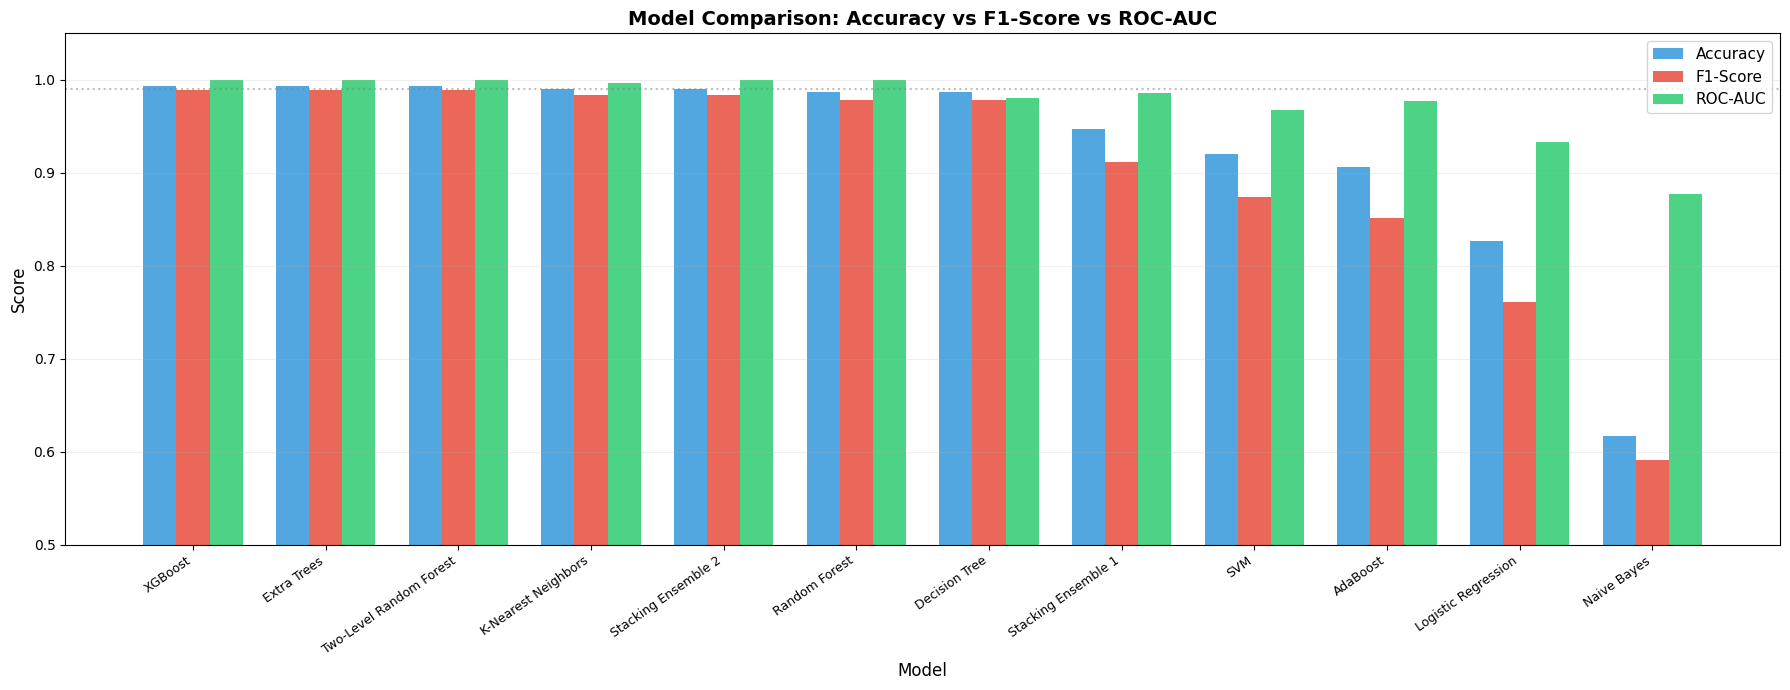

In [ ]:
models_to_plot = all_results_df_p1.dropna(subset=['F1-Score']).copy()
metrics = ['Accuracy', 'F1-Score', 'ROC-AUC']

x = np.arange(len(models_to_plot))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

fig, ax = plt.subplots(figsize=(18, 7))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = models_to_plot[metric].astype(float)
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85, edgecolor='none')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Accuracy vs F1-Score vs ROC-AUC', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(models_to_plot.index, rotation=35, ha='right', fontsize=9)
ax.set_ylim(0.5, 1.05)
ax.legend(fontsize=11)
ax.axhline(y=0.99, color='gray', linestyle=':', alpha=0.5)
ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

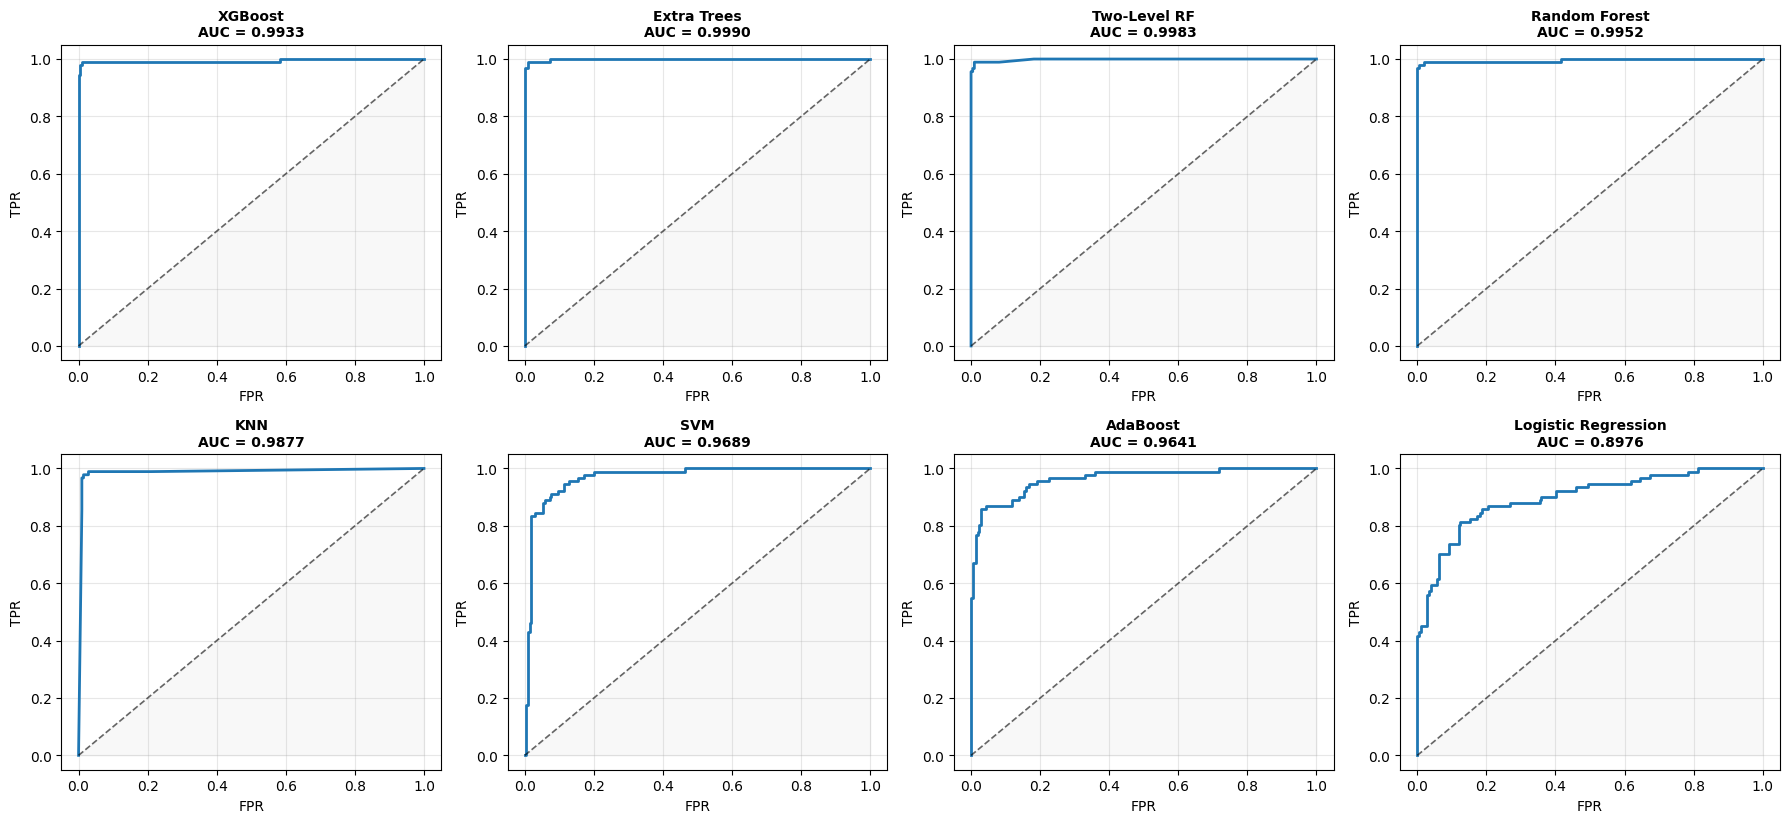

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

# Re-collect probabilities for all models on test set
roc_models = {
    'XGBoost': trained_models_p1['XGBoost'].predict_proba(X_test_selected_p1)[:, 1],
    'Extra Trees': trained_models_p1['Extra Trees'].predict_proba(X_test_selected_p1)[:, 1],
    'Two-Level RF': rf_level2.predict_proba(level1_test_preds)[:, 1],
    'Random Forest': trained_models_p1['Random Forest'].predict_proba(X_test_selected_p1)[:, 1],
    'KNN': trained_models_p1['K-Nearest Neighbors'].predict_proba(X_test_selected_p1)[:, 1],
    'SVM': trained_models_p1['SVM'].predict_proba(X_test_selected_p1)[:, 1],
    'AdaBoost': trained_models_p1['AdaBoost'].predict_proba(X_test_selected_p1)[:, 1],
    'Logistic Regression': trained_models_p1['Logistic Regression'].predict_proba(X_test_selected_p1)[:, 1],
}

# Create 3x4 grid
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, (name, probs) in enumerate(roc_models.items()):
    fpr, tpr, _ = roc_curve(y_test_p1, probs)
    auc = roc_auc_score(y_test_p1, probs)

    ax = axes[i]
    ax.plot(fpr, tpr, linewidth=2)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6)
    ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

    ax.set_title(f'{name}\nAUC = {auc:.4f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.grid(alpha=0.3)

# Hide unused subplots (since we have 10 models but 12 slots)
for j in range(len(roc_models), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:

print("\n" + "="*80)
print("12. COMPREHENSIVE XAI SUMMARY")
print("="*80)

# Create comparison table
xai_summary = pd.DataFrame({
    'Method': ['SHAP', 'Permutation Importance', 'Gradient Importance', 'Mutual Information'],
    'Type': ['Model-agnostic', 'Model-agnostic', 'Model-specific (DL)', 'Filter method'],
    'Scope': ['Local + Global', 'Global', 'Global', 'Global'],
    'Computational Cost': ['High', 'Medium', 'Low', 'Low'],
    'Interpretability': ['High', 'High', 'Medium', 'High']
})

print("\nXAI Methods Comparison:")
print(xai_summary.to_string(index=False))

# Summary of all XAI outputs
print("\n" + "="*80)
print("XAI OUTPUTS GENERATED")
print("="*80)
print("Traditional ML:")
print("  ✓ SHAP summary plot (violin)")
print("  ✓ SHAP bar plot (feature importance)")
print("  ✓ SHAP waterfall plot (single prediction)")
print("  ✓ Feature importance analysis")
print("  ✓ Permutation importance")
print("\nDeep Learning:")
print("  ✓ Gradient-based feature importance")
print("  ✓ SHAP summary for neural network")
print("\nHyperparameter Tuning:")
print("  ✓ Learning rate effect")
print("  ✓ Batch size effect")
print("  ✓ Dropout rate effect")
print("  ✓ Top configurations comparison")

print("\n✅ ALL XAI ANALYSES COMPLETE!")


12. COMPREHENSIVE XAI SUMMARY

XAI Methods Comparison:
                Method                Type          Scope Computational Cost Interpretability
                  SHAP      Model-agnostic Local + Global               High             High
Permutation Importance      Model-agnostic         Global             Medium             High
   Gradient Importance Model-specific (DL)         Global                Low           Medium
    Mutual Information       Filter method         Global                Low             High

XAI OUTPUTS GENERATED
Traditional ML:
  ✓ SHAP summary plot (violin)
  ✓ SHAP bar plot (feature importance)
  ✓ SHAP waterfall plot (single prediction)
  ✓ Feature importance analysis
  ✓ Permutation importance

Deep Learning:
  ✓ Gradient-based feature importance
  ✓ SHAP summary for neural network

Hyperparameter Tuning:
  ✓ Learning rate effect
  ✓ Batch size effect
  ✓ Dropout rate effect
  ✓ Top configurations comparison

✅ ALL XAI ANALYSES COMPLETE!


In [ ]:

# ============================================================================
# 13. FINAL TEST SET EVALUATION
# ============================================================================

print("\n" + "="*80)
print("13. FINAL TEST SET EVALUATION (Top 3 Models)")
print("="*80)

top_3 = all_results_df_p1.head(3).index.tolist()
test_results_p1 = {}

for model_name in top_3:
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print('='*60)

    if model_name == 'Two-Level Random Forest':
        y_test_pred_p1 = rf_level2.predict(level1_test_preds)
        y_test_prob_p1 = rf_level2.predict_proba(level1_test_preds)[:, 1]
    elif 'Stacking' in model_name:
        if model_name == 'Stacking Ensemble 1':
            y_test_pred_p1 = stacking_1.predict(X_test_selected_p1)
            y_test_prob_p1 = stacking_1.predict_proba(X_test_selected_p1)[:, 1]
        else:
            y_test_pred_p1 = stacking_2.predict(X_test_selected_p1)
            y_test_prob_p1 = stacking_2.predict_proba(X_test_selected_p1)[:, 1]
    else:
        model = trained_models_p1[model_name]
        y_test_pred_p1 = model.predict(X_test_selected_p1)
        y_test_prob_p1 = model.predict_proba(X_test_selected_p1)[:, 1]

    test_results_p1[model_name] = {
        'Accuracy': accuracy_score(y_test_p1, y_test_pred_p1),
        'Precision': precision_score(y_test_p1, y_test_pred_p1),
        'Recall': recall_score(y_test_p1, y_test_pred_p1),
        'F1-Score': f1_score(y_test_p1, y_test_pred_p1),
        'ROC-AUC': roc_auc_score(y_test_p1, y_test_prob_p1),
        'Specificity': recall_score(y_test_p1, y_test_pred_p1, pos_label=0),
        'MCC': matthews_corrcoef(y_test_p1, y_test_pred_p1)
    }

    print(classification_report(y_test_p1, y_test_pred_p1, target_names=['No PCOS', 'PCOS']))

test_results_df_p1 = pd.DataFrame(test_results_p1).T
print("\n" + "="*80)
print("FINAL TEST SET PERFORMANCE (Top 3 Models)")
print("="*80)
print(test_results_df_p1.round(4))



13. FINAL TEST SET EVALUATION (Top 3 Models)

Evaluating: XGBoost
              precision    recall  f1-score   support

     No PCOS       1.00      0.99      0.99       209
        PCOS       0.98      0.99      0.98        91

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300


Evaluating: Extra Trees
              precision    recall  f1-score   support

     No PCOS       1.00      0.99      0.99       209
        PCOS       0.98      0.99      0.98        91

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300


Evaluating: Two-Level Random Forest
              precision    recall  f1-score   support

     No PCOS       1.00      0.99      0.99       209
        PCOS       0.98      0.99      0.98        91

    accuracy                           0.99       300

In [ ]:

# ============================================================================
# 14. SUMMARY & COMPARISON
# ============================================================================

print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)

print(f"\nDataset Statistics:")
print(f"  Total samples: {len(df_train_clean)}")
print(f"  Original features: 44")
print(f"  Final features: {len(feature_names_p1)}")
print(f"  Selected features (TOMIM): {len(selected_features_p1)}")

print(f"\nData Split:")
print(f"  Training: {len(X_train_p1)} ({len(X_train_p1)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val_p1)} ({len(X_val_p1)/len(X)*100:.1f}%)")
print(f"  Test: {len(X_test_p1)} ({len(X_test_p1)/len(X)*100:.1f}%)")

print(f"\nModels Evaluated:")
print(f"  Traditional ML: 9")
print(f"  Stacking Ensembles: 2")
print(f"  Two-Level RF: 1")
print(f"  TOTAL: 12 models")

print(f"\n📊 COMPARISON WITH SmartScanPCOS PAPER:")
print(f"  Paper's Best (Two-Level RF): 99.31%")
print(f"  Our Two-Level RF:            {two_rf_results_p1['Accuracy']*100:.2f}%")
print(f"  Our Best Model ({best_model}): {all_results_df_p1.loc[best_model, 'Accuracy']*100:.2f}%")


print("\n" + "="*80)
print("✓ PIPELINE COMPLETE!")
print("="*80)



FINAL SUMMARY

Dataset Statistics:
  Total samples: 2000
  Original features: 44
  Final features: 40
  Selected features (TOMIM): 16

Data Split:
  Training: 1400 (70.0%)
  Validation: 300 (15.0%)
  Test: 300 (15.0%)

Models Evaluated:
  Traditional ML: 9
  Stacking Ensembles: 2
  Two-Level RF: 1
  TOTAL: 12 models

📊 COMPARISON WITH SmartScanPCOS PAPER:
  Paper's Best (Two-Level RF): 99.31%
  Our Two-Level RF:            99.33%
  Our Best Model (XGBoost): 99.33%

✓ PIPELINE COMPLETE!


EXPLAINABLE AI (XAI) FOCUS ON BEST MODEL: **XGBOOST**

In [ ]:
# Extract names of features selected during the TOMIM step
selected_features_p1 = [feature_names_p1[i] for i in selected_indices_p1]

In [ ]:
# Access your best XGBoost model
best_xgb = trained_models_p1["XGBoost"]

# Create the explainer
explainer = shap.TreeExplainer(best_xgb)

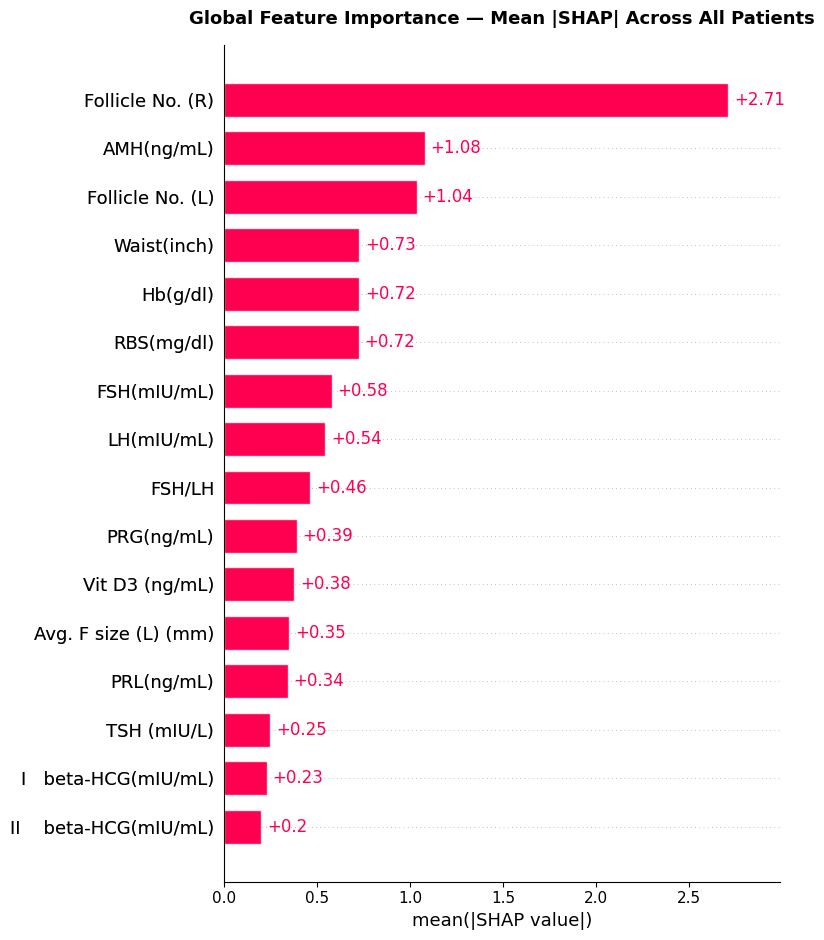

In [ ]:
# Calculate SHAP values for ALL test patients
explainer = shap.Explainer(best_xgb, X_train_selected_p1, feature_names=selected_features_p1)
shap_values_all = explainer(X_test_selected_p1)

# ============================================================
# 1. BAR PLOT — Mean absolute SHAP value per feature (global average)
# ============================================================
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values_all, max_display=16, show=False)
plt.title("Global Feature Importance — Mean |SHAP| Across All Patients",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# DEFINE best_model_name_p1 from Part 1 results
# (best_model was set in the model comparison cell above)
# ============================================================================
best_model_name_p1 = best_model   # Part 1 best model name (e.g. 'XGBoost')
print(f"Part 1 best model: {best_model_name_p1}")


Part 1 best model: XGBoost


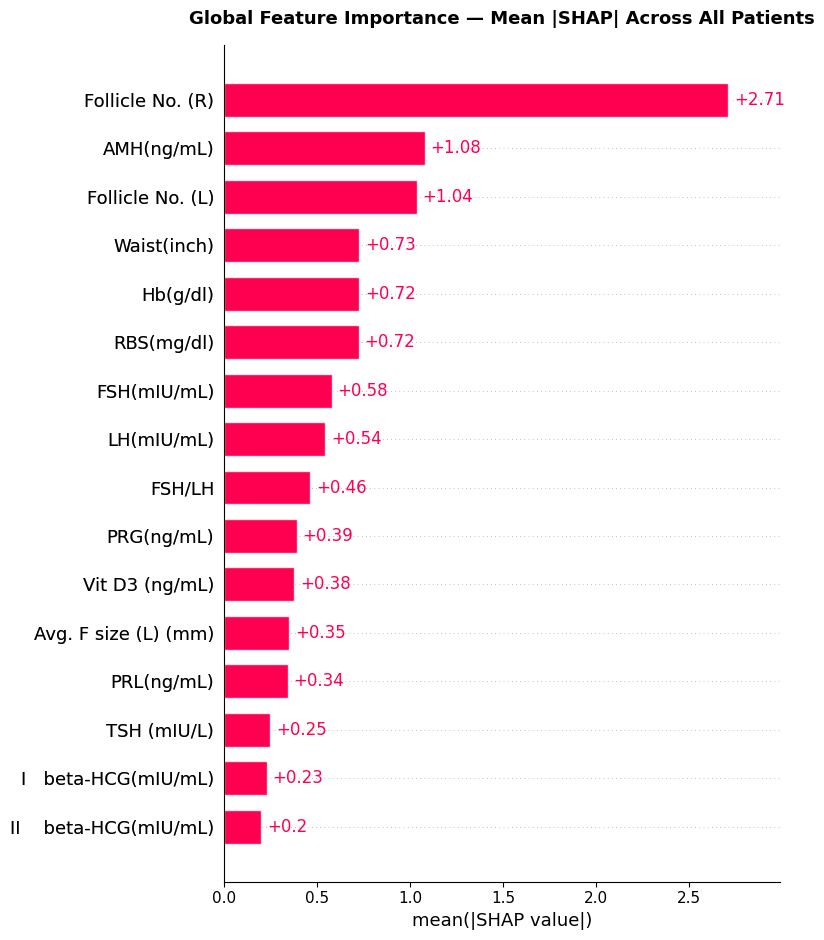

In [ ]:
# Calculate SHAP values for ALL test patients
explainer = shap.Explainer(best_xgb, X_train_selected_p1, feature_names=selected_features_p1)
shap_values_all = explainer(X_test_selected_p1)

# ============================================================
# 1. BAR PLOT — Mean absolute SHAP value per feature (global average)
# ============================================================
plt.figure(figsize=(10, 7))
shap.plots.bar(shap_values_all, max_display=16, show=False)
plt.title("Global Feature Importance — Mean |SHAP| Across All Patients",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

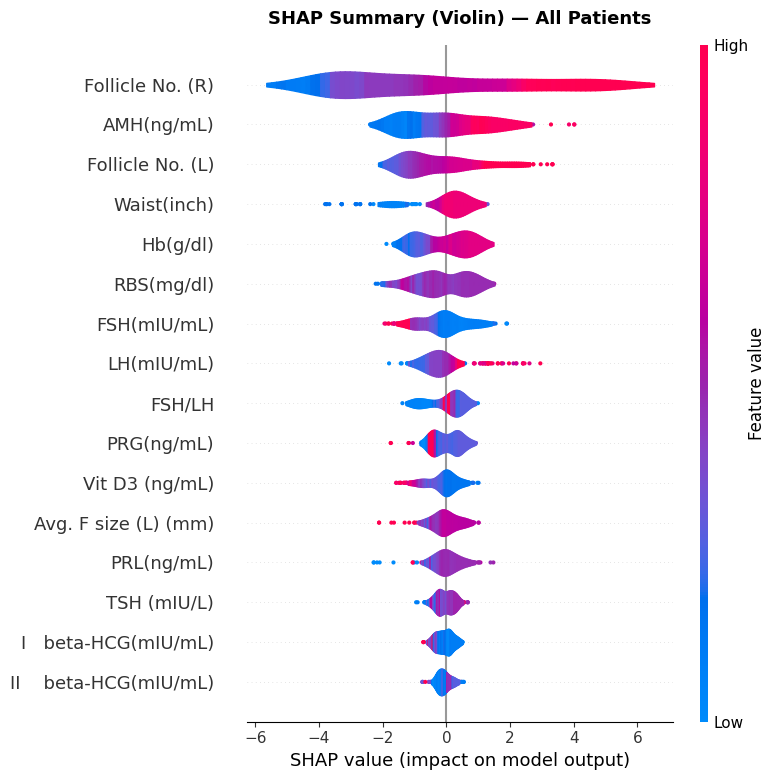

In [ ]:

# ============================================================
# 2. VIOLIN / SUMMARY PLOT — Classic view (color = feature value)
# ============================================================
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_all.values, X_test_selected_p1,
                  feature_names=selected_features_p1,
                  plot_type='violin', show=False)
plt.title("SHAP Summary (Violin) — All Patients",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

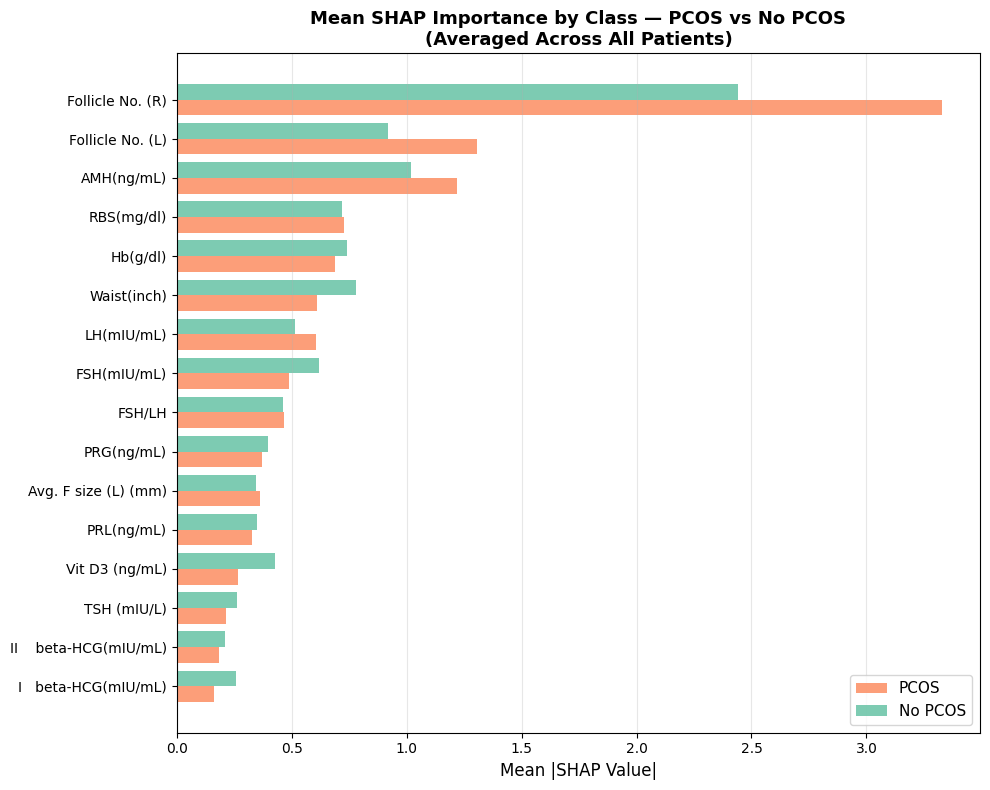


Global SHAP Importance (Mean |SHAP| across ALL test patients):
               Feature  Mean |SHAP|  Mean SHAP (PCOS)  Mean SHAP (No PCOS)
      Follicle No. (R)       2.7103            3.3279               2.4413
            AMH(ng/mL)       1.0782            1.2188               1.0170
      Follicle No. (L)       1.0355            1.3070               0.9173
           Waist(inch)       0.7266            0.6095               0.7776
              Hb(g/dl)       0.7249            0.6874               0.7413
            RBS(mg/dl)       0.7230            0.7294               0.7203
           FSH(mIU/mL)       0.5789            0.4893               0.6179
            LH(mIU/mL)       0.5431            0.6068               0.5153
                FSH/LH       0.4644            0.4678               0.4629
            PRG(ng/mL)       0.3900            0.3710               0.3984
        Vit D3 (ng/mL)       0.3789            0.2678               0.4272
  Avg. F size (L) (mm)       0.3492 

In [ ]:

# ============================================================
# 3. MEAN SHAP BAR — Separated by class (PCOS vs No PCOS)
# ============================================================
y_test_arr = y_test_p1.values
pcos_idx    = np.where(y_test_arr == 1)[0]
no_pcos_idx = np.where(y_test_arr == 0)[0]

mean_shap_pcos    = np.abs(shap_values_all.values[pcos_idx]).mean(axis=0)
mean_shap_no_pcos = np.abs(shap_values_all.values[no_pcos_idx]).mean(axis=0)

shap_compare = pd.DataFrame({
    'Feature':    selected_features_p1,
    'PCOS':       mean_shap_pcos,
    'No PCOS':    mean_shap_no_pcos
}).sort_values('PCOS', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(shap_compare))
ax.barh(y_pos - 0.2, shap_compare['PCOS'],    height=0.4,
        label='PCOS',    color='#fc8d62', alpha=0.85)
ax.barh(y_pos + 0.2, shap_compare['No PCOS'], height=0.4,
        label='No PCOS', color='#66c2a5', alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels(shap_compare['Feature'], fontsize=10)
ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('Mean SHAP Importance by Class — PCOS vs No PCOS\n(Averaged Across All Patients)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Print numeric summary
print("\nGlobal SHAP Importance (Mean |SHAP| across ALL test patients):")
print("=" * 55)
global_mean = pd.DataFrame({
    'Feature':          selected_features_p1,
    'Mean |SHAP|':      np.abs(shap_values_all.values).mean(axis=0),
    'Mean SHAP (PCOS)': mean_shap_pcos,
    'Mean SHAP (No PCOS)': mean_shap_no_pcos
}).sort_values('Mean |SHAP|', ascending=False)
print(global_mean.round(4).to_string(index=False))

In [ ]:
# Install feyn if not already installed
!pip install feyn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.4/329.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.4 MB/s eta 0:00:00


Best model summary:


<?xml version="1.0" encoding="utf-8" ?>
<svg baseProfile="full" height="264.0" preserveAspectRatio="none" version="1.1" viewBox="0 0 891 264.0" width="891" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs /><svg class="graph" height="155.0" width="711" x="0" y="0"><defs /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="601" y="50.0"><title>target
logistic:
w=2.8553
bias=0.4497</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="646.0" y="71.5">target</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="689" y="59.0">0</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="603" y="59.0">logistic</text><line stroke="#1E1E1E" x1="571" x2="601" y1="67.5" y2="67.5" /><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="481" y="50.0"><title>add</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="526.0" y="71.5">add</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="569" y="59.0">1</text><line stroke="#1E1E1E" x1="451" x2="481" y1="37.5" y2="58.5" /><line stroke="#1E1E1E" x1="451" x2="481" y1="97.5" y2="76.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="361" y="20.0"><title>AMH(ng/mL)
linear:
scale=0.204857
scale offset=0.040545
w=1.757772
bias=-0.5007</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="41.5">AMH(ng/mL)</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="29.0">2</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="363" y="29.0">num</text><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="361" y="80.0"><title>add</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="406.0" y="101.5">add</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="449" y="89.0">3</text><line stroke="#1E1E1E" x1="331" x2="361" y1="37.5" y2="88.5" /><line stroke="#1E1E1E" x1="331" x2="361" y1="97.5" y2="106.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="241" y="20.0"><title>Follicle No. (R)
linear:
scale=0.443076
scale offset=0.108291
w=1.334771
bias=-0.1417</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="41.5">Follicle..</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="29.0">4</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="start" x="243" y="29.0">num</text><rect class="node" fill="#FAFAFA" height="35" stroke="#FF1EC8" stroke-width="1" width="90" x="241" y="80.0"><title>gaussian</title></rect><text fill="#1E1E1E" font-family="monospace" font-size="12" style="pointer-events:none" text-anchor="middle" x="286.0" y="101.5">gaussian</text><text fill="#1E1E1E" font-family="monospace" font-size="10" style="pointer-events:none" text-anchor="end" x="329" y="89.0">5</text><line stroke="#1E1E1E" x1="211" x2="241" y1="37.5" y2="88.5" /><line stroke="#1E1E1E" x1="211" x2="241" y1="97.5" y2="106.5" /><rect class="node" fill="#00F082" height="35" stroke="#1E1E1E" stroke-width="1" width="90" x="121" y="20.0"><title>Waist(inch)
linear:
scale=0.312702
scale offse
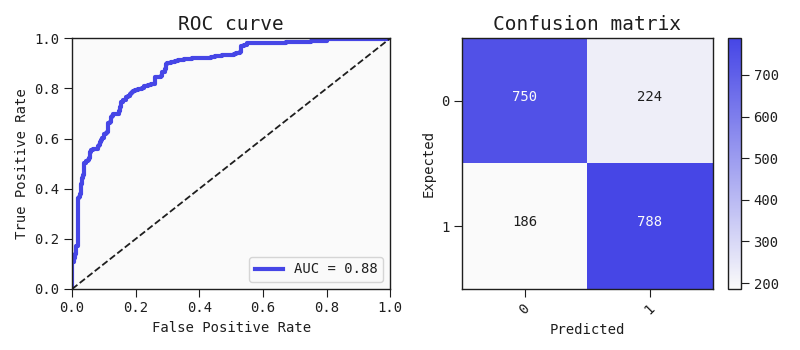

In [ ]:
import feyn
import pandas as pd
import numpy as np

# Connect to QLattice
ql = feyn.QLattice(random_seed=42)

# Prepare training dataframe
train_df = pd.DataFrame(X_train_selected_p1, columns=selected_features_p1)
train_df['target'] = y_train_balanced.values

# Auto-run to find best model
models = ql.auto_run(
    train_df,
    output_name='target',
    kind='classifier',
    n_epochs=10
)

# Display best QLattice graph
best_model = models[0]

# ── Fixed: use correct feyn v2+ attributes ──
print("Best model summary:")
print(best_model)

# Display the QLattice graph inline
best_model.plot(data=train_df)

In [ ]:
# Install dalex if not already installed
!pip install dalex

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 68.7 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [ ]:
import dalex as dx
import pandas as pd
import numpy as np

X_train_df = pd.DataFrame(X_train_selected_p1, columns=selected_features_p1)
X_test_df  = pd.DataFrame(X_test_selected_p1,  columns=selected_features_p1)

explainer = dx.Explainer(
    model   = trained_models_p1['XGBoost'],
    data    = X_train_df,
    y       = y_train_balanced.values,
    label   = 'XGBClassifier',
    verbose = False
)
print("✓ Explainer ready.")


# ============================================================================
# (A) VARIABLE IMPORTANCE — Permutation Drop-out Loss
# ============================================================================
vi = explainer.model_parts(
    type         = 'difference',
    N            = None,
    B            = 10,
    random_state = 42
)

vi_plot = vi.plot(
    title     = 'Variable Importance',
    bar_width = 16,
    show      = False
)

vi_plot.update_layout(
    width        = 800,
    height       = 500,
    plot_bgcolor = 'white',
    paper_bgcolor= 'white',
    font         = dict(family='Arial', size=12),
    title_text   = 'Variable Importance',
    title_x      = 0.01,
    title_font   = dict(size=14, color='#2c3e50'),
    showlegend   = False,
    margin       = dict(l=180, r=40, t=60, b=60)
)
vi_plot.update_xaxes(
    gridcolor       = '#eeeeee',
    showgrid        = True,
    zeroline        = True,
    zerolinecolor   = '#cccccc',
    zerolinewidth   = 1
)
vi_plot.update_yaxes(
    title_text = '',
    showgrid   = False
)

# Style bars: teal color matching your reference image
vi_plot.update_traces(
    marker_color      = '#00b4d8',
    marker_line_color = '#0077b6',
    marker_line_width = 0.5
)

vi_plot.show()


# ============================================================================
# (B) BREAK DOWN PLOT — Local explanation (first PCOS-positive test case)
# ============================================================================
y_test_arr   = np.array(y_test_p1)
chosen_idx   = np.where(y_test_arr == 1)[0][0]
single_obs   = X_test_df.iloc[[chosen_idx]]

print(f"Explaining → index: {chosen_idx} | "
      f"True: PCOS={y_test_arr[chosen_idx]} | "
      f"Predicted prob: {trained_models_p1['XGBoost'].predict_proba(single_obs)[0,1]:.4f}")

bd = explainer.predict_parts(
    new_observation = single_obs,
    type            = 'break_down',
    label           = 'XGBClassifier'
)

bd_plot = bd.plot(
    title     = 'Break Down',
    bar_width = 16,
    show      = False
)

bd_plot.update_layout(
    width         = 850,
    height        = 520,
    plot_bgcolor  = 'white',
    paper_bgcolor = 'white',
    font          = dict(family='Arial', size=12),
    title_text    = 'Break Down',
    title_x       = 0.01,
    title_font    = dict(size=14, color='#2c3e50'),
    showlegend    = False,
    margin        = dict(l=220, r=40, t=60, b=60)
)
bd_plot.update_xaxes(
    gridcolor     = '#eeeeee',
    showgrid      = True,
    zeroline      = True,
    zerolinecolor = '#333333',
    zerolinewidth = 1.5
)
bd_plot.update_yaxes(
    title_text = '',
    showgrid   = False
)

bd_plot.show()

✓ Explainer ready.


Explaining → index: 0 | True: PCOS=1 | Predicted prob: 0.9704


In [ ]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
# ============================================================================
# LIME — Local Explanation for PCOS-Positive Case
# ============================================================================
import lime
import lime.lime_tabular
import numpy as np
import pandas as pd

X_train_df = pd.DataFrame(X_train_selected_p1, columns=selected_features_p1)
X_test_df  = pd.DataFrame(X_test_selected_p1,  columns=selected_features_p1)

# ── LIME Explainer ──
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train_selected_p1,
    feature_names   = selected_features_p1,
    class_names     = ['No PCOS', 'PCOS'],
    mode            = 'classification',
    random_state    = 42
)

# ── Pick first PCOS-positive test instance ──
y_test_arr   = np.array(y_test_p1)
chosen_idx   = np.where(y_test_arr == 1)[0][0]
single_obs   = X_test_selected_p1[chosen_idx]

pred_prob = trained_models_p1['XGBoost'].predict_proba(single_obs.reshape(1, -1))[0]
print(f"Instance index      : {chosen_idx}")
print(f"True label          : PCOS = {y_test_arr[chosen_idx]}")
print(f"P(No PCOS)          : {pred_prob[0]:.4f}")
print(f"P(PCOS)             : {pred_prob[1]:.4f}")

# ── Generate LIME explanation ──
explanation = lime_explainer.explain_instance(
    data_row        = single_obs,
    predict_fn      = trained_models_p1['XGBoost'].predict_proba,
    num_features    = 10,      # top 10 features shown
    num_samples     = 5000,
    labels          = (1,)     # explain PCOS class
)

# ── Display inline in Colab (matches your reference style exactly) ──
explanation.show_in_notebook(
    show_table  = True,
    show_all    = False
)

Instance index      : 0
True label          : PCOS = 1
P(No PCOS)          : 0.0296
P(PCOS)             : 0.9704


In [ ]:
print("=" * 80)
print("STORING FINAL PIPELINE 1 OUTPUT")
print("=" * 80)

# Get best trained model
best_model_pipe1 = trained_models_p1[best_model_name_p1]

# Generate predictions on test set
y_pred_pipe1 = best_model_pipe1.predict(X_test_selected_p1)

# (Optional) probabilities
y_prob_pipe1 = best_model_pipe1.predict_proba(X_test_selected_p1)[:, 1]

print(f"Stored predictions for Pipeline 1: {best_model_name_p1}")
print(f"Length check: {len(y_pred_pipe1)} vs {len(y_test_p1)}")

STORING FINAL PIPELINE 1 OUTPUT
Stored predictions for Pipeline 1: XGBoost
Length check: 300 vs 300


In [ ]:
for name, obj in list(globals().items()):
    if any(word in name.lower() for word in ['model', 'pipeline', 'clf', 'estimator', 'trained', 'best', 'ensemble']):
        print(f"{name:40s} → {type(obj).__name__}")

simple_models                            → dict
tunable_models                           → dict
trained_models_p1                        → dict
best_params_dict                         → dict
model                                    → ExtraTreesClassifier
best_model                               → Model
models_to_plot                           → DataFrame
roc_models                               → dict
model_name                               → str
best_xgb                                 → XGBClassifier
best_model_name_p1                       → str
models                                   → list
best_model_pipe1                         → XGBClassifier


In [ ]:
import pickle
import os
from google.colab import files

with open("p1_model.pkl", "wb") as f:
    pickle.dump(best_model_pipe1, f)

print("✓ p1_model.pkl saved!")
print("Path:", os.path.abspath("p1_model.pkl"))
files.download("p1_model.pkl")

✓ p1_model.pkl saved!
Path: /content/p1_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ── Step 1: Define TOMIMSelector (copy from app.py) ──────────────────────────
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif
import numpy as np

class TOMIMSelector(BaseEstimator, TransformerMixin):
    def __init__(self, random_state=42, percentile=0):
        self.random_state  = random_state
        self.percentile    = percentile
        self.selected_idx_ = None
        self.threshold_    = None

    def fit(self, X, y):
        mi = mutual_info_classif(X, y, random_state=self.random_state)
        self.threshold_    = np.percentile(mi, self.percentile)
        self.selected_idx_ = np.where(mi >= self.threshold_)[0]
        if len(self.selected_idx_) == 0:
            self.selected_idx_ = np.argsort(mi)[-5:]
        return self

    def transform(self, X):
        return X[:, self.selected_idx_]

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return [input_features[i] for i in self.selected_idx_]
        return self.selected_idx_

# ── Step 2: Build and save the full pipeline ─────────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pickle

tomim_p1 = TOMIMSelector(random_state=RANDOM_STATE, percentile=0)
tomim_p1.selected_idx_ = np.array(selected_indices_p1)
tomim_p1.threshold_    = threshold

p1_full_pipeline = Pipeline([
    ("imputer",  SimpleImputer(strategy="median")),
    ("scaler",   StandardScaler()),
    ("selector", tomim_p1),
    ("model",    trained_models_p1[best_model_name_p1]),
])

# Fit imputer and scaler on the original pre-SMOTE training data
# (selector and model are already fitted — Pipeline will skip refitting them
#  since we're using set_params after construction)
p1_full_pipeline.named_steps["imputer"].fit(X_train_p1)
p1_full_pipeline.named_steps["scaler"].fit(
    p1_full_pipeline.named_steps["imputer"].transform(X_train_p1)
)

with open("p1_model.pkl", "wb") as f:
    pickle.dump(p1_full_pipeline, f)

with open("p1_features.pkl", "wb") as f:
    pickle.dump(feature_names_p1, f)

print("✓ p1_model.pkl saved!")
print(f"  Pipeline: imputer → scaler → TOMIM ({len(selected_indices_p1)} features) → {best_model_name_p1}")
print(f"  Feature order saved to p1_features.pkl ({len(feature_names_p1)} features)")

✓ p1_model.pkl saved!
  Pipeline: imputer → scaler → TOMIM (16 features) → XGBoost
  Feature order saved to p1_features.pkl (40 features)


In [ ]:
# ── Step 3: Smoke test ────────────────────────────────────────────────────────
test_pipe = pickle.load(open("p1_model.pkl", "rb"))

# Pass a single raw row (unscaled, unimputed) — pipeline should handle it
sample = X_train_p1.iloc[[0]]
pred  = test_pipe.predict(sample)
proba = test_pipe.predict_proba(sample)
print(f"✓ Smoke test passed — pred: {pred}, proba: {proba}")

✓ Smoke test passed — pred: [1], proba: [[0.0043357 0.9956643]]
